# A look into generated patterns

just a few more renders of generated patterns with different random seeds.

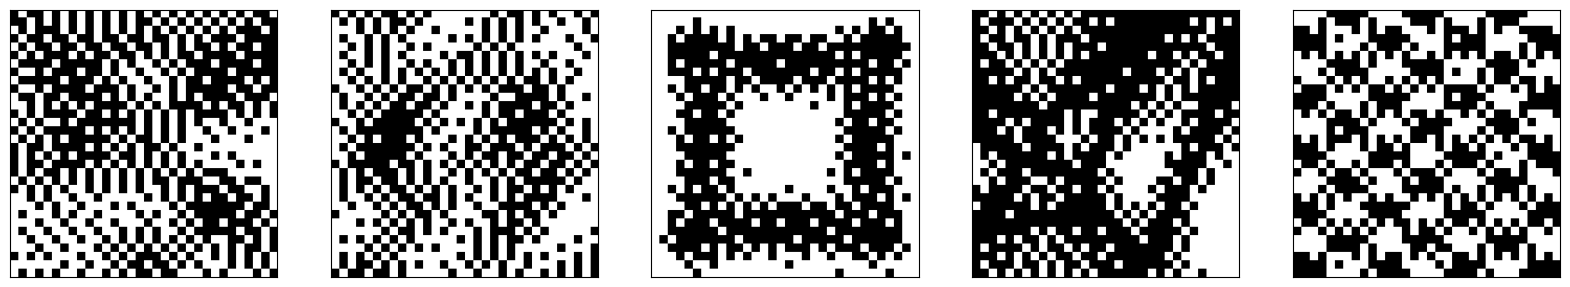

In [36]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))
from pixelfy import Pixelfy, PixelfyOps
from PIL import Image

import matplotlib.pyplot as plt
import os 
import pattern 

def fig_images(imgs):
    fig, axs = plt.subplots(1,len(imgs), figsize=(4*len(imgs),4))
    axs = axs.ravel()
    
    for img, ax in zip(imgs, axs):
        ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])
    return fig, axs
    
palette = [(0,0,0),(255,255,255)]
generators = [
    pattern.NoiseGenerator,
    pattern.PlasmaGenerator,
    pattern.ReactionDiffusionGenerator,
    pattern.VoronoiGenerator,
    pattern.WaveGenerator]
seed = [187 for i in generators]

imgs = list()
for gen, seed in zip(generators, seed):
    img = gen(seed=seed).generate()
    img = img.convert("RGB")
    img = PixelfyOps.variable_dither(img, strength=0.55, palette=palette)
    img = img.resize((320, 320), Image.NEAREST)
    imgs.append(img)

fig, axs = fig_images(imgs)

In [37]:
from collections.abc import Iterable

def _broadcast(value, length: int):
    """Broadcast scalar to list or validate existing list."""
    if isinstance(value, (str, bytes)) or not isinstance(value, Iterable):
        return [value] * length
    else:
        lst = list(value)
        if len(lst) != length:
            raise ValueError(f"Expected length {length}, got {len(lst)}")
        return lst


def image_set(generator, seed):
    if isinstance(generator, Iterable) and not isinstance(generator, (str, bytes)): 
        length = len(generator)
    elif isinstance(seed, Iterable) and not isinstance(seed, (str, bytes)):
        length = len(seed)
    else:
        raise TypeError("At least one argument must be a list/iterable")
    
    generator = _broadcast(generator, length)
    seed = _broadcast(seed, length)

    imgs = list()
    for gen, seed in zip(generator, seed):
        img = gen(seed=seed).generate()
        img = img.convert("RGB")
        img = PixelfyOps.variable_dither(img, strength=0.55, 
                                         palette=[(0,0,0),(255,255,255)])
        img = img.resize((320, 320), Image.NEAREST)
        imgs.append(img)

    return imgs


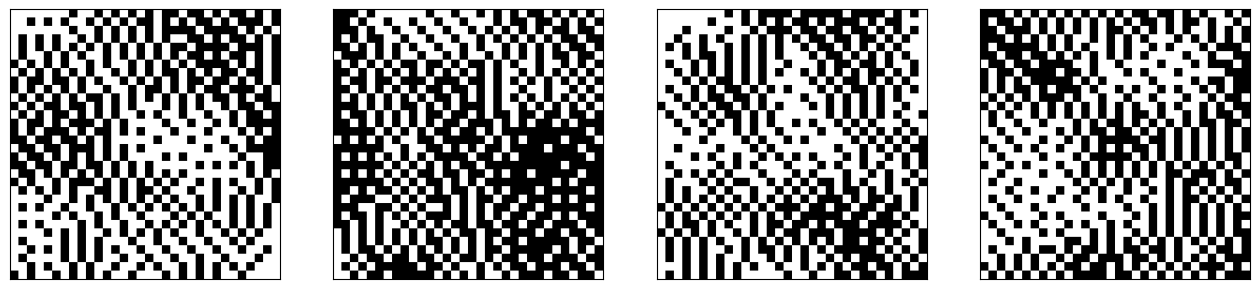

In [38]:
imgs = image_set(pattern.NoiseGenerator, range(0,4))
fig, axs = fig_images(imgs)

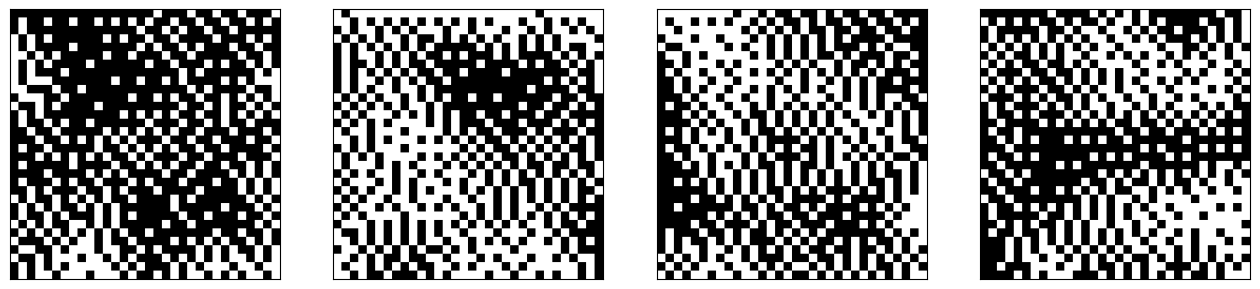

In [22]:
imgs = image_set(pattern.NoiseGenerator, range(4,8))
fig, axs = fig_images(imgs)

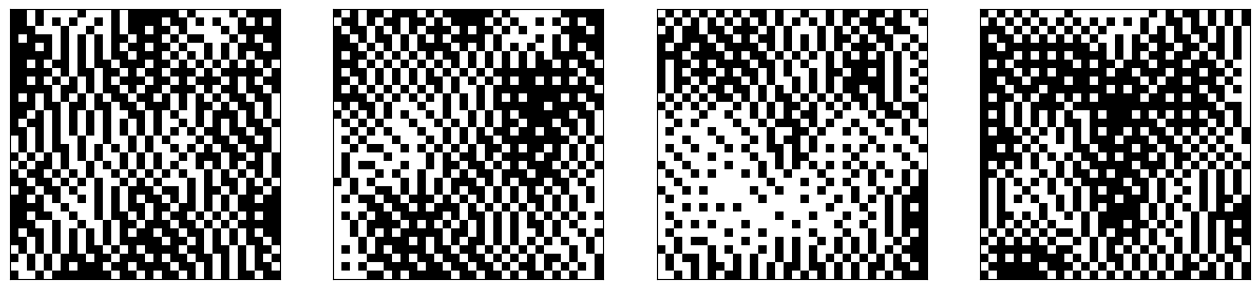

In [23]:
imgs = image_set(pattern.NoiseGenerator, range(8,12))
fig, axs = fig_images(imgs)

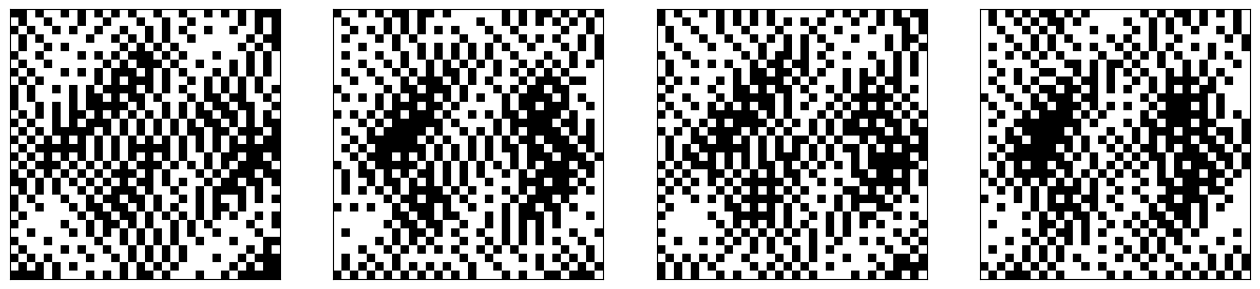

In [28]:
imgs = image_set(pattern.PlasmaGenerator, range(0,4))
fig, axs = fig_images(imgs)

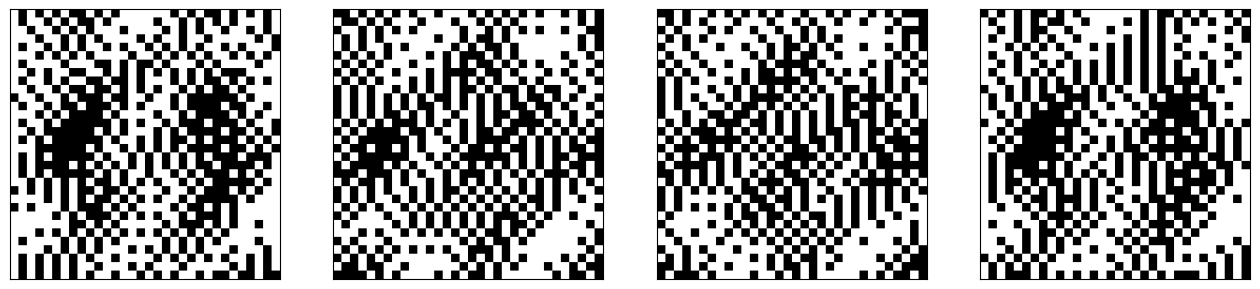

In [26]:
imgs = image_set(pattern.PlasmaGenerator, range(4,8))
fig, axs = fig_images(imgs)

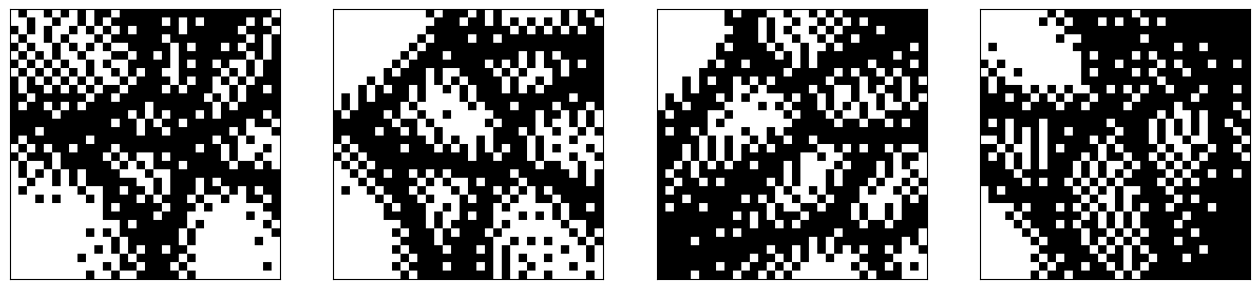

In [29]:
imgs = image_set(pattern.VoronoiGenerator, range(0,4))
fig, axs = fig_images(imgs)

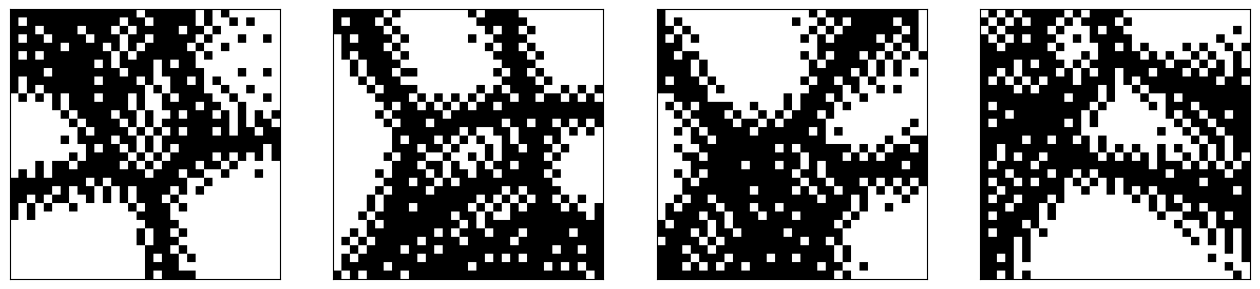

In [30]:
imgs = image_set(pattern.VoronoiGenerator, range(4,8))
fig, axs = fig_images(imgs)

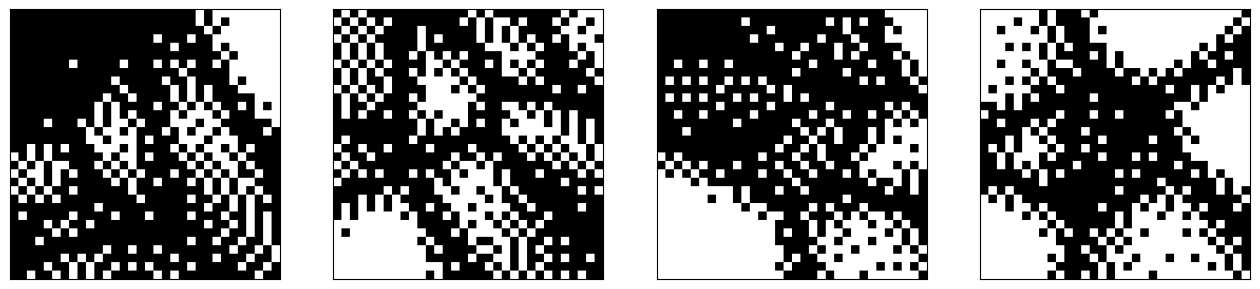

In [31]:
imgs = image_set(pattern.VoronoiGenerator, range(8,12))
fig, axs = fig_images(imgs)

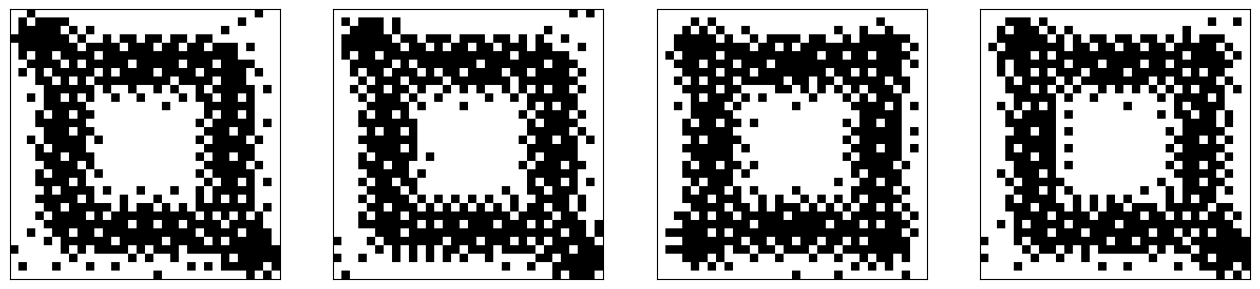

In [33]:
imgs = image_set(pattern.ReactionDiffusionGenerator, range(0,4))
fig, axs = fig_images(imgs)

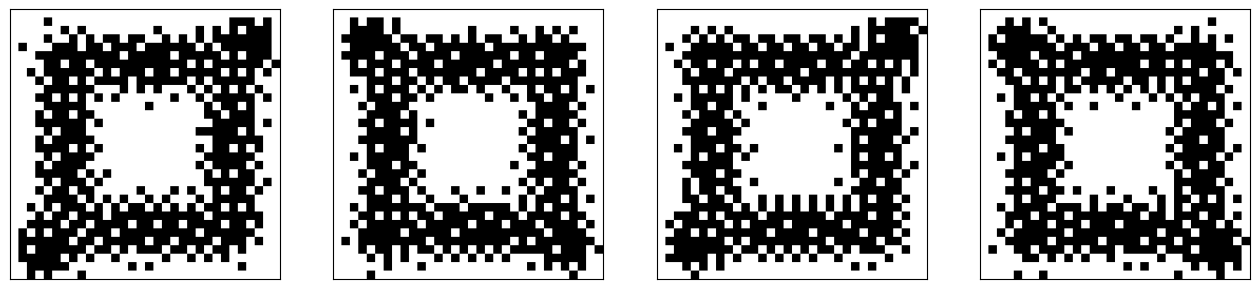

In [34]:
imgs = image_set(pattern.ReactionDiffusionGenerator, range(4,8))
fig, axs = fig_images(imgs)

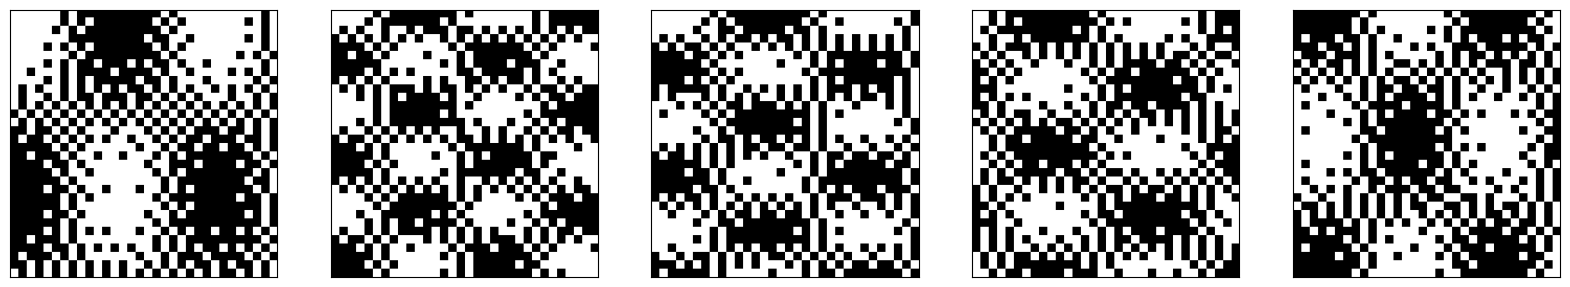

In [71]:
imgs = image_set(pattern.WaveGenerator, [2,15,23, 38,74])
fig, axs = fig_images(imgs)